# AI/ML Bootcamp Lecture 4

## MNIST Handwritten digit classifier continued
For this in-class exercise we will look at the MNIST handwritten digit dataset and classify them using different types of neural networks using keras and tensorflow.

### Imports and style

In [ ]:
from tensorflow.keras.datasets import mnist
from tensorflow import keras
from tensorflow.keras import layers
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import pandas as pd
import matplotlib.pyplot as plt
height = 5
plt.rcParams["figure.figsize"] = [1.618*height, height]

### Load the MNIST data into a NumPy arrays

In [ ]:
from tensorflow.keras.datasets import mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


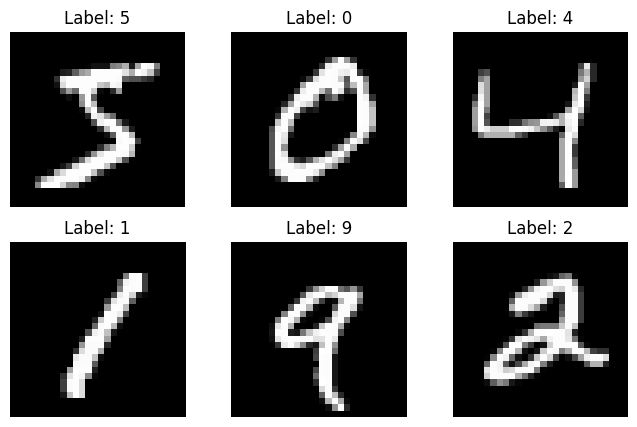

In [ ]:
# Plot 6 images from the training set
plt.figure()
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(train_images[i], cmap='gray')
    plt.title(f"Label: {train_labels[i]}")
    plt.axis('off')

In [ ]:
# Build a MLP model
model = keras.Sequential()
model.add(layers.Flatten(input_shape=(28, 28)))  # Flatten the input images
model.add(layers.Dense(512, activation='relu'))  # Hidden layer with 128
model.add(layers.Dense(512, activation='relu'))  # Hidden layer with 128
model.add(layers.Dense(512, activation='relu'))  # Hidden layer with 128
model.add(layers.Dense(10, activation='softmax'))  # Output layer with 10 classes

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Train the model
history = model.fit(train_images, train_labels, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8992 - loss: 0.9649 - val_accuracy: 0.9429 - val_loss: 0.2107
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9488 - loss: 0.1888 - val_accuracy: 0.9488 - val_loss: 0.1804
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9561 - loss: 0.1577 - val_accuracy: 0.9438 - val_loss: 0.2656
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9617 - loss: 0.1406 - val_accuracy: 0.9618 - val_loss: 0.1575
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9650 - loss: 0.1316 - val_accuracy: 0.9640 - val_loss: 0.1441
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9689 - loss: 0.1202 - val_accuracy: 0.9663 - val_loss: 0.1340
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9700 - loss: 0.1197 - val_accuracy: 0.9647 - val_loss: 0.1501
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9772 - loss: 0.0893 - 

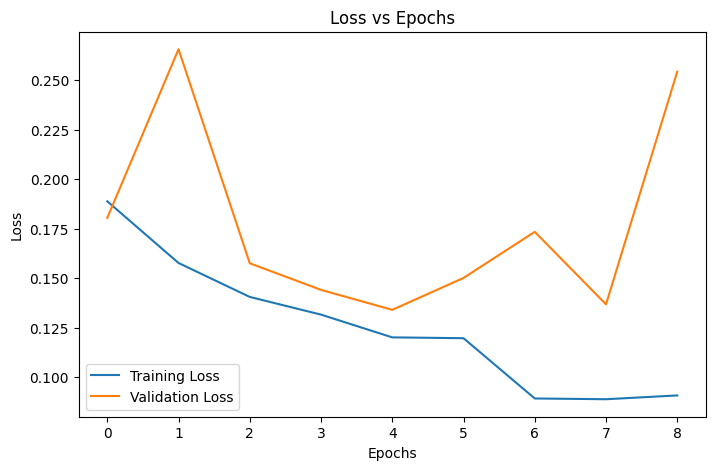

In [ ]:
# Plot loss and val loss
plt.figure()
plt.plot(history.history['loss'][1:], label='Training Loss')
plt.plot(history.history['val_loss'][1:], label='Validation Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend();

### Early Stopping Callback

In [ ]:
# Build a MLP model
model = keras.Sequential()
model.add(layers.Flatten(input_shape=(28, 28)))  # Flatten the input images
model.add(layers.Dense(512, activation='relu'))  # Hidden layer with 128
model.add(layers.Dense(512, activation='relu'))  # Hidden layer with 128
model.add(layers.Dense(512, activation='relu'))  # Hidden layer with 128
model.add(layers.Dense(10, activation='softmax'))  # Output layer with 10 classes

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Example of early stopping with callbacks
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10)
history = model.fit(train_images,
                    train_labels,
                    epochs=50,
                    validation_split=0.2,
                    callbacks=[early_stopping])

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8949 - loss: 1.0407 - val_accuracy: 0.9374 - val_loss: 0.2175
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9497 - loss: 0.1824 - val_accuracy: 0.9562 - val_loss: 0.1674
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9559 - loss: 0.1579 - val_accuracy: 0.9557 - val_loss: 0.1718
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9600 - loss: 0.1446 - val_accuracy: 0.9515 - val_loss: 0.1877
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9649 - loss: 0.1305 - val_accuracy: 0.9616 - val_loss: 0.1565
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9680 - loss: 0.1186 - val_accuracy: 0.9661 - val_loss: 0.1350
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9741 - loss: 0.1005 - val_accuracy: 0.9635 - val_loss: 0.1599
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9755 - loss: 0.0916 - 

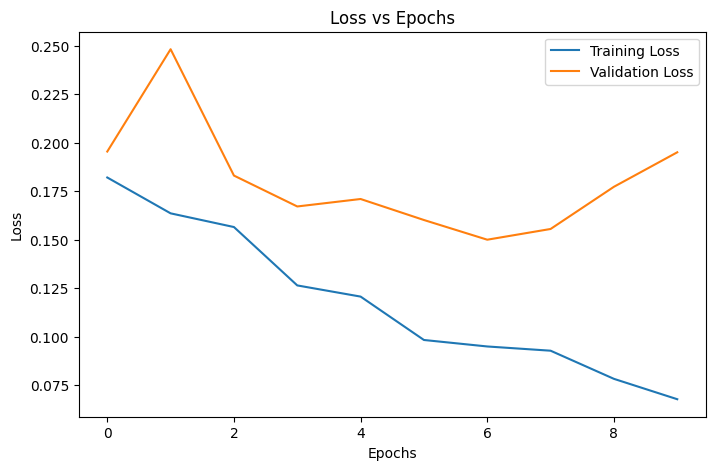

In [ ]:
# Plot loss and val loss
plt.figure()
plt.plot(history.history['loss'][1:], label='Training Loss')
plt.plot(history.history['val_loss'][1:], label='Validation Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend();

### Model Evaluation

In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f'Test accuracy: {test_acc}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9706 - loss: 0.2204
Test accuracy: 0.9706000089645386


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


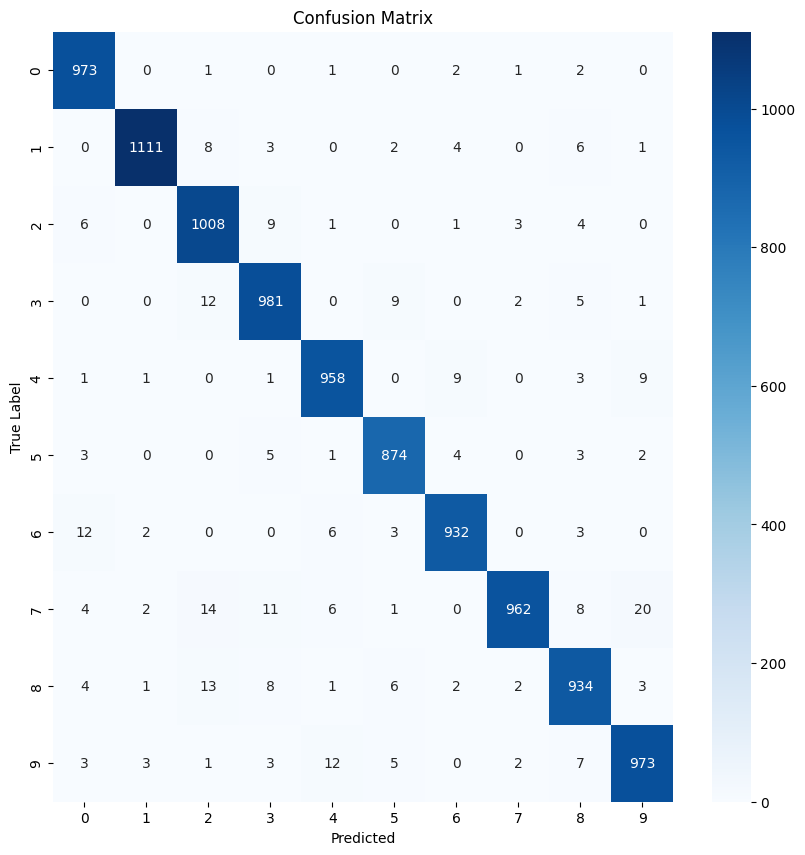

In [ ]:
# Plot confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
predictions = model.predict(test_images)
predictions = predictions.argmax(axis=1)
cm = confusion_matrix(test_labels, predictions)
plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True Label')
plt.title("Confusion Matrix")
plt.show()

### Hyperparameter optimization

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Install Keras Tuner
!pip install -q -U keras-tuner

In [ ]:
TUNING_DIR = "/content/drive/MyDrive/mnist_tuning_lecture4"

os.makedirs(TUNING_DIR, exist_ok=True)

In [ ]:
# Helper function that builds our model
def build_model(hp):

    neurons = hp.Choice("neurons", values=[256, 512, 1024]) # First hyperparameter
    n_layers = hp.Choice("n_layers", values=[1, 2, 3]) # Second hyperparameter

    model = keras.Sequential()
    model.add(layers.Flatten(input_shape=(28, 28)))  # Flatten the input images
    for i in range(n_layers):
      model.add(layers.Dense(neurons, activation='relu'))  # Hidden layer
    model.add(layers.Dense(10, activation='softmax'))  # Output layer with 10
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [ ]:
import keras_tuner as kt

In [ ]:
import keras_tuner as kt

tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=5,
    executions_per_trial=2,
    directory=TUNING_DIR,
    overwrite=False,
    project_name="n_neuron_search")

tuner.search(train_images,
             train_labels,
             epochs=10,
             validation_split=0.2,
             verbose=1)

best_hp = tuner.get_best_hyperparameters(1)[0]

print(f"Best # neurons per layer: {best_hp}")

Trial 3 Complete [00h 02m 22s]
val_accuracy: 0.9682083427906036

Best val_accuracy So Far: 0.9682083427906036
Total elapsed time: 00h 06m 06s
Best # neurons per layer: <keras_tuner.src.engine.hyperparameters.hyperparameters.HyperParameters object at 0x7c21bac953a0>


In [ ]:
print(f"Best # neurons per layer: {best_hp.get("neurons")}")

Best # neurons per layer: 1024


### Convolutional Neural Network

In [ ]:
# Build a CNN model
model = keras.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

# # Compile the model
# model.compile(optimizer='adam',
#               loss='sparse_categorical_crossentropy',
#               metrics=['accuracy'])
# Compile the model with adam with the learning rate set 1E-4
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1E-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Model description
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 726,986 (2.77 MB)

 Trainable params: 726,986 (2.77 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Create an early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10)

# Train the model
history = model.fit(train_images, train_labels, epochs=100, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9001 - loss: 0.4689 - val_accuracy: 0.9475 - val_loss: 0.1981
Epoch 2/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9624 - loss: 0.1305 - val_accuracy: 0.9627 - val_loss: 0.1464
Epoch 3/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9757 - loss: 0.0803 - val_accuracy: 0.9668 - val_loss: 0.1320
Epoch 4/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9830 - loss: 0.0540 - val_accuracy: 0.9740 - val_loss: 0.1014
Epoch 5/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9879 - loss: 0.0382 - val_accuracy: 0.9758 - val_loss: 0.0952
Epoch 6/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9895 - loss: 0.0310 - val_accuracy: 0.9783 - val_loss: 0.0919
Epoch 7/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9927 - loss: 0.0219 - val_accuracy: 0.9792 - val_loss: 0.0956
Epoch 8/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9937 - loss: 

[]

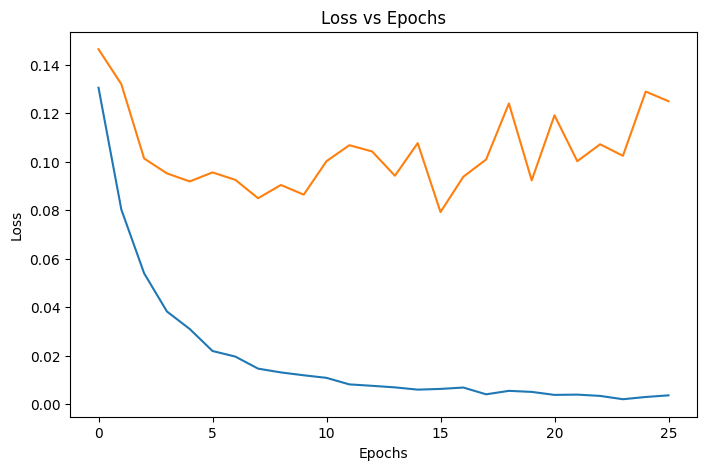

In [ ]:
# Plot history
plt.figure()
plt.plot(history.history['loss'][1:], label='Training Loss')
plt.plot(history.history['val_loss'][1:], label='Validation Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.plot()

In [ ]:
# Look at accuracy
model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9841 - loss: 0.1054


[0.10535170882940292, 0.9840999841690063]

# CIFAR 10 Example

In [ ]:
# load training data
(train_images, train_labels), (test_images, test_labels) = keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
# Normalization step, optional but improves results
import numpy as np
np.max(train_images)
if np.max(train_images) > 1:
  train_images = train_images / 255
  test_images = test_images / 255

In [ ]:
class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

In [ ]:
# Plot 25 images
plt.figure(figsize=(20, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

NameError: name 'plt' is not defined

In [ ]:
train_images.shape

(50000, 32, 32, 3)

In [ ]:
model = keras.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10)
history = model.fit(train_images, train_labels, epochs=100, validation_split=0.2)#, callbacks=[early_stopping])

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.4326 - loss: 1.5542 - val_accuracy: 0.5234 - val_loss: 1.3173
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5796 - loss: 1.1824 - val_accuracy: 0.5969 - val_loss: 1.1415
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6331 - loss: 1.0311 - val_accuracy: 0.6492 - val_loss: 0.9897
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6754 - loss: 0.9267 - val_accuracy: 0.6600 - val_loss: 0.9584
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7056 - loss: 0.8445 - val_accuracy: 0.6890 - val_loss: 0.8869
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7229 - loss: 0.7869 - val_accuracy: 0.6880 - val_loss: 0.9153
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7449 - loss: 0.7249 - val_accuracy: 0.6888 - val_loss: 0.9279
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7596 - loss:

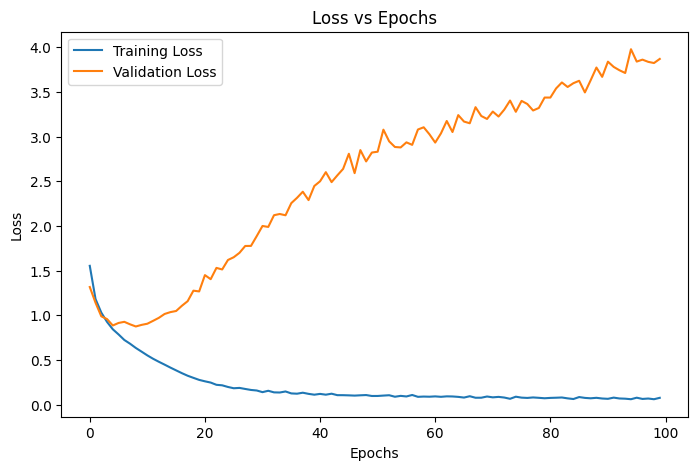

In [ ]:
# Plot loss and val loss
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend();